In [12]:
import os
from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing in your .env")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [13]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI



In [14]:
load_dotenv()


True

In [15]:

chat_llm = ChatOpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    model="llama-3.3-70b-versatile",
    temperature=0.7
)

In [16]:
response = chat_llm.invoke("Hello, how are you?")
print(response.content)

Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you might have. How can I help you today?


In [17]:
from typing_extensions import TypedDict, Annotated
import operator

In [18]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [19]:

class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [21]:
{
    "messages": [HumanMessage(content="Hi, this is Pratyush. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Pratyush. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [23]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [24]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [25]:
from langgraph.graph import StateGraph

In [26]:
builder = StateGraph(GraphState)

In [27]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [28]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [29]:
app = builder.compile()

In [30]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [31]:
from IPython.display import Image, display

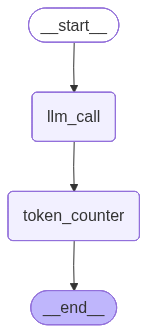

In [32]:
display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Pratyush. Say hello in detail.")]
})

In [34]:
result

{'messages': [HumanMessage(content='Hi, this is Pratyush. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Pratyush, it's an absolute pleasure to connect with you. I hope this message finds you in the best of spirits and having a fantastic day so far. My name is Assistant, and I'm an artificial intelligence language model designed to provide information, answer questions, and engage in conversations on a wide range of topics.\n\nI'm excited to learn more about your interests, hobbies, and what brings you here today. Whether you have a specific question in mind, need help with a particular topic, or just want to chat about your day, I'm all ears (or rather, all text). I'm here to listen, provide assistance, and offer any guidance or support you might need.\n\nSo, please feel free to share a bit about yourself, and we can get this conversation started. What's been on your mind lately? Is there something specific you'd like to talk about, or d

In [35]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Pratyush. Say hello in detail.
AIMessage : Hello Pratyush, it's an absolute pleasure to connect with you. I hope this message finds you in the best of spirits and having a fantastic day so far. My name is Assistant, and I'm an artificial intelligence language model designed to provide information, answer questions, and engage in conversations on a wide range of topics.

I'm excited to learn more about your interests, hobbies, and what brings you here today. Whether you have a specific question in mind, need help with a particular topic, or just want to chat about your day, I'm all ears (or rather, all text). I'm here to listen, provide assistance, and offer any guidance or support you might need.

So, please feel free to share a bit about yourself, and we can get this conversation started. What's been on your mind lately? Is there something specific you'd like to talk about, or do you have a particular topic in mind that you're curious about? I'm here to help

In [40]:
# Count token
import tiktoken
# check the length of the token
encoding = tiktoken.get_encoding("cl100k_base")
print("Token count:", len(encoding.encode(result["messages"][-1].content)))

Token count: 14


In [75]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [76]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [77]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [78]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly s'